In [1]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.
X shape: (4217, 128, 128, 3) y shape: (4217,)


In [2]:
# Importar la función
import sys
sys.path.append('../')

import importlib
import models.complejo_2_cnn
importlib.reload(models.complejo_2_cnn) # recargamos el cache para tener la ultima versión del modelo 
from models.complejo_2_cnn import create_model


# Crear el modelo
model = create_model() # con learning rate de 0.001 no converje 

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 122, 122, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 122, 122, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 122, 122, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 57, 57, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 57, 57, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,724 (776.27 KB)

 Trainable params: 197,508 (771.52 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [4]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 103s 996ms/step - accuracy: 0.3076 - loss: 2.4294 - val_accuracy: 0.2607 - val_loss: 1.7700
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.3586 - loss: 2.0638 - val_accuracy: 0.2927 - val_loss: 1.8413
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.3788 - loss: 1.8316 - val_accuracy: 0.3732 - val_loss: 1.8916
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.3899 - loss: 1.7641 - val_accuracy: 0.3910 - val_loss: 1.8076
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.4207 - loss: 1.6507 - val_accuracy: 0.3555 - val_loss: 1.8349
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.4579 - loss: 1.5721 - val_accuracy: 0.3697 - val_loss: 1.8954
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4437 - loss: 1.5750 - val_accuracy: 0.3507 - val_loss: 1.9051
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.4634 - loss: 1.5274 - val_accuracy: 0

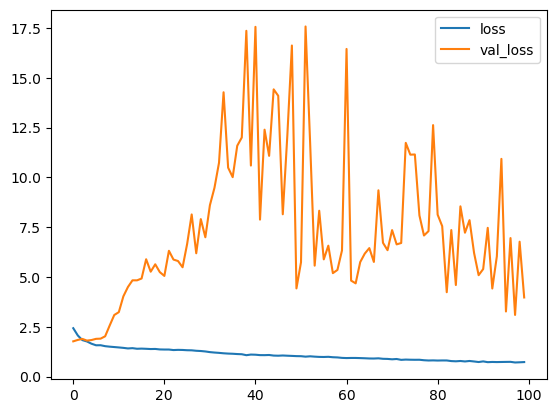

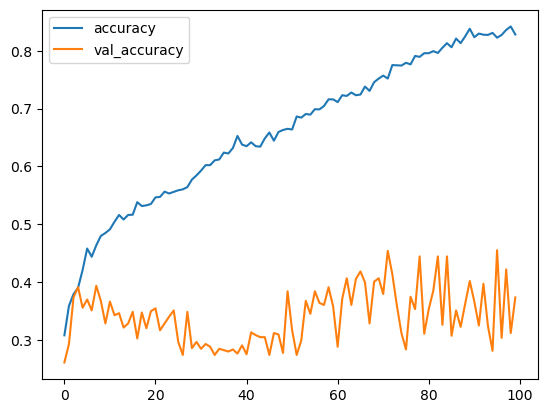

In [ ]:
import matplotlib.pyplot as plt
# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss')
ax[0].plot( val_loss, label='Val loss')
ax[0].set_title('Training evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss')
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss')
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

# Visualizacion de accuracy durante el entrenamiento
plt.plot(hist.history["accuracy"], label= "accuracy")
plt.plot(hist.history["val_accuracy"], label ="val_accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.show()

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)
df.round(3)


80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step


,Train,Val,Test
Accuracy,0.382,0.373,0.336
F1,0.366,0.364,0.332


In [7]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

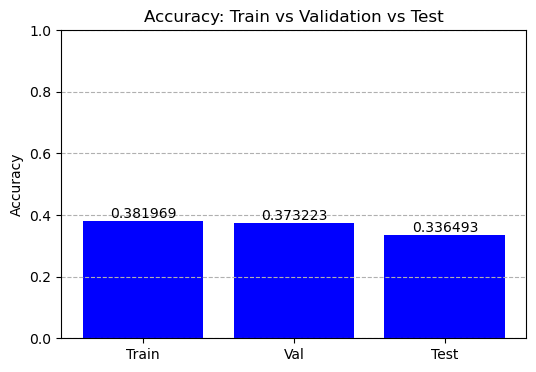

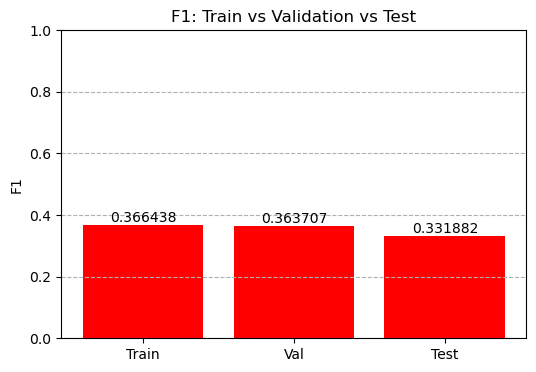

In [8]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step


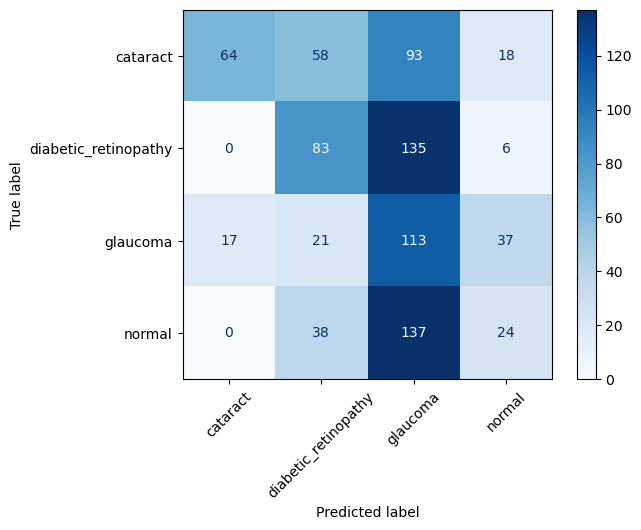

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [10]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)

80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.316,0.462,0.340,0.483,0.275,0.408
diabetic_retinopathy,0.407,0.410,0.381,0.405,0.371,0.392
glaucoma,0.688,0.418,0.672,0.386,0.601,0.339
normal,0.129,0.188,0.126,0.188,0.121,0.169
